<a href="https://colab.research.google.com/github/AureliaVDB/TickIt_Data_Pipeline/blob/main/TickIt_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q
!pip install delta-spark -q

In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import IntegerType, TimestampType, BooleanType, DataType, DecimalType
import os, glob, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [4]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("TickIt_Medallion_Pipeline")
    .getOrCreate()
)

In [5]:
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/TickIt_Project"

RAW = f"{BASE}/raw"  # csv files
BRONZE = f"{BASE}/bronze"  # storage for bronze layer
SILVER = f"{BASE}/silver"  # storage for silver layer
GOLD = f"{BASE}/gold"  # storage for gold layer

for path in [RAW, BRONZE, SILVER, GOLD]:
    os.makedirs(path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Bronze Layer

In [6]:
# list of all the source files
raw_files = []
for f in os.listdir(RAW):
    if f.endswith(".csv"):
        raw_files.append(f)

print(f"files in list: {raw_files}")

files in list: ['orders.csv', 'payments.csv', 'events.csv', 'event_categories.csv', 'ticket_types.csv', 'customers.csv', 'reviews.csv']


In [7]:
for file in raw_files:
  input_path = os.path.join(RAW, file)
  table_name = os.path.splitext(file)[0]
  output_path = os.path.join(BRONZE, table_name)

  df = spark.read.csv(input_path, header=True) # load the raw data
  df.write.mode("overwrite").parquet(output_path) # write to bronze layer

  print(f"{table_name.upper()}")
  print()
  print("Schema")
  df.printSchema()
  print(f"Row Count: {df.count()}")
  print()
  print("Sample Records")
  df.show(5)
  print()

ORDERS

Schema
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

Row Count: 52520

Sample Records
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|      order_id|     customer_id|event_id|ticket_type_id|         order_date|event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|    ORD0039854|b2744cf668394fac| EVT0050|       TT00106|2022-08-15 10:00:00|2022-09-03|       2|   completed|      NULL|
|    ORD0002676|ad9181b36ee84121| EVT0092|       TT00194|2021-04-15 23:00:00|20

Silver Layer

In [8]:
bronze_tables = {}

for folder_name in os.listdir(BRONZE):
  folder_path = os.path.join(BRONZE, folder_name)
  if os.path.isdir(folder_path):
    bronze_tables[folder_name] = spark.read.parquet(folder_path)


In [9]:
#Orders

orders_raw = bronze_tables["orders"]

orders_raw.printSchema()

orders_raw.show(5)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|      order_id|     customer_id|event_id|ticket_type_id|         order_date|event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|    ORD0039854|b2744cf668394fac| EVT0050|       TT00106|2022-08-15 10:00:00|2022-09-03|       2|   completed|      NULL|
|    ORD0002676|ad9181b36ee84121| EVT0092|       TT00194|2021-04-15 23:00:00|2021-06-30|       6|   completed|      NULL|
|    

In [10]:
# fixing variable type
orders_cleaned = (
    orders_raw.withColumn("quantity", F.col("quantity").cast(IntegerType()))
    .withColumn("order_date", F.to_timestamp(F.col("order_date")))
    .withColumn("event_date", F.to_date(F.col("event_date")))
)

orders_cleaned.printSchema()
orders_cleaned.show(5, truncate=False)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- event_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0039854    |b2744cf668394fac|EVT0050 |TT00106       |2022-08-15 10:00:00|2022-09-03|2       |completed   |NULL      |
|ORD0002676    |ad9181b36ee84121|EVT0092 |TT00194       |2021-04-15 23:00:00|2021-06-30|6       |completed   |NULL      |
|OR

In [11]:
# nullable

orders_cleaned.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in [
            "order_id",
            "customer_id",
            "event_id",
            "ticket_type_id",
            "order_date",
            "quantity",
            "promo_code",
        ]
    ]
).show()

+--------+-----------+--------+--------------+----------+--------+----------+
|order_id|customer_id|event_id|ticket_type_id|order_date|quantity|promo_code|
+--------+-----------+--------+--------------+----------+--------+----------+
|       0|        270|       0|             0|         0|       0|     29352|
+--------+-----------+--------+--------------+----------+--------+----------+



In [12]:

missing_customers = orders_cleaned.filter(F.col("customer_id").isNull())

print(f"Total rows with missing customer_id: {missing_customers.count()}")
missing_customers.show(10, truncate=False)


Total rows with missing customer_id: 270
+----------+-----------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id  |customer_id|event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+----------+-----------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0037574|NULL       |EVT0181 |TT00366       |2022-04-12 06:00:00|2022-04-20|4       |completed   |NULL      |
|ORD0003884|NULL       |EVT0340 |TT00705       |2022-10-17 19:00:00|2022-11-13|4       |completed   |STUDENT15 |
|ORD0037061|NULL       |EVT0408 |TT00835       |2025-04-18 08:00:00|2025-05-08|1       |completed   |NULL      |
|ORD0008603|NULL       |EVT0256 |TT00532       |2022-10-30 04:00:00|2022-12-06|2       |completed   |NULL      |
|ORD0012328|NULL       |EVT0118 |TT00240       |2022-06-01 17:00:00|2022-06-16|1       |completed   |NULL      |
|ORD0043240|NULL       |EVT0240 |TT00492       |2024-12

In [13]:
total_orders = orders_cleaned.count()
distinct_orders = orders_cleaned.select("order_id").distinct().count()

print(f"Total Rows: {total_orders}")
print(f"Distinct Order IDs: {distinct_orders}")
print(f"Duplicate Order IDs found: {total_orders - distinct_orders}")

Total Rows: 52520
Distinct Order IDs: 52520
Duplicate Order IDs found: 0


In [14]:
orders_silver = orders_cleaned.fillna({"customer_id": "GUEST"})

orders_silver.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in ["order_id", "customer_id", "quantity", "promo_code"]
    ]
).show()

+--------+-----------+--------+----------+
|order_id|customer_id|quantity|promo_code|
+--------+-----------+--------+----------+
|       0|          0|       0|     29352|
+--------+-----------+--------+----------+



In [15]:
# check quantity for unrealistic number

orders_silver.select("quantity").describe().show()

quantiles = orders_silver.approxQuantile(
    "quantity", [0.25, 0.50, 0.75, 0.95, 0.99, 1.0], 0.01
)
print("Percentiles [25%, 50%, 75%, 95%, 99%, Max]:", quantiles)

+-------+------------------+
|summary|          quantity|
+-------+------------------+
|  count|             52520|
|   mean| 2.547981721249048|
| stddev|1.3551327100983674|
|    min|                 0|
|    max|                 6|
+-------+------------------+

Percentiles [25%, 50%, 75%, 95%, 99%, Max]: [2.0, 2.0, 3.0, 5.0, 6.0, 6.0]


In [16]:
dup_orders = orders_silver.filter(F.col("order_id").contains("_DUP"))

print(f"Total records with '_DUP' in order_id: {dup_orders.count()}")
dup_orders.show(10, truncate=False)

Total records with '_DUP' in order_id: 520
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0048203_DUP|1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
|ORD0027374_DUP|e771cb9cbded4054|EVT0076 |TT00155       |2024-03-04 22:00:00|2024-05-31|1       |completed   |NULL      |
|ORD0003043_DUP|bfc8ed144bd74aa8|EVT0240 |TT00492       |2024-07-20 23:00:00|2024-08-17|2       |completed   |SUMMER10  |
|ORD0022897_DUP|c844312a9119439f|EVT0067 |TT00135       |2024-10-03 16:00:00|2024-10-08|1       |completed   |NULL      |
|ORD0021446_DUP|25d94a5b1da34368|EVT0301 |TT00625       |2023-05-29 04:00:00|2023-06-05|6       |comple

In [18]:
orders_silver.filter(
    (F.col("order_id") == "ORD0048203") | (F.col("order_id") == "ORD0048203_DUP")
).show(truncate=False)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0048203_DUP|1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
|ORD0048203    |1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+



In [20]:
orders_silver = orders_silver.withColumn(
    "order_id", F.regexp_replace(F.col("order_id"), "_DUP", "")
)

orders_silver = orders_silver.dropDuplicates(["order_id"])


In [21]:
orders_silver.groupBy("order_status").count().orderBy(
    F.col("count").desc()
).show(truncate=False)

+------------+-----+
|order_status|count|
+------------+-----+
|completed   |38223|
|cancelled   |8042 |
|confirmed   |3176 |
|no_show     |2559 |
+------------+-----+



In [22]:
orders_silver_path = os.path.join(SILVER, "orders")
orders_silver.write.mode("overwrite").parquet(orders_silver_path)

In [23]:
# Customers
customers_raw = bronze_tables["customers"]

customers_raw.printSchema()

customers_raw.show(5, truncate=False)

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- registration_date: string (nullable = true)
 |-- date_of_birth: string (nullable = true)

+----------------+--------------------------------+----------+---------+-------------------------+-------+------------+--------------+-----------------+-------------+
|customer_id     |customer_unique_id              |first_name|last_name|email                    |city   |country_code|country       |registration_date|date_of_birth|
+----------------+--------------------------------+----------+---------+-------------------------+-------+------------+--------------+-----------------+-------------+
|7ff8bab402524574|4988c52bf1bf47f2b6e3ef3fe0eeb9d3|Simon     |Torre

In [24]:
customers_cleaned = (
     customers_raw
     .withColumn(
        "registration_date",
        F.to_date(
            F.regexp_replace(
                F.regexp_replace(F.col("registration_date"), "/", "-"), # dates are often written with /
                r"^(\d{2})-(\d{2})-(\d{4})$",
                r"$3-$2-$1"
            )
        )
    )
    .withColumn(
        "date_of_birth",
        F.to_date(
            F.regexp_replace(
                F.regexp_replace(F.col("date_of_birth"), "/", "-"),
                r"^(\d{2})-(\d{2})-(\d{4})$",
                r"$3-$2-$1"
            )
        )
    )
)
customers_cleaned.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- registration_date: date (nullable = true)
 |-- date_of_birth: date (nullable = true)



In [25]:
customers_cleaned.select(
    F.count("*").alias("total_rows"),
    F.count_distinct("customer_id").alias("distinct_customer_ids"),
    F.count_distinct("customer_unique_id").alias("distinct_unique_ids"),
    F.sum(F.when(F.col("customer_id").isNull(), 1).otherwise(0)).alias("null_customer_ids")
).show()

+----------+---------------------+-------------------+-----------------+
|total_rows|distinct_customer_ids|distinct_unique_ids|null_customer_ids|
+----------+---------------------+-------------------+-----------------+
|     10800|                10800|              10692|                0|
+----------+---------------------+-------------------+-----------------+



In [26]:
# Trim whitespace from text fields and lowercase email for consistency
customers_silver = (
    customers_cleaned
    .withColumn("first_name", F.trim(F.col("first_name")))
    .withColumn("last_name", F.trim(F.col("last_name")))
    .withColumn("email", F.lower(F.trim(F.col("email"))))
    .withColumn("city", F.trim(F.col("city")))
    .withColumn("country", F.trim(F.col("country")))
    .withColumn("country_code", F.upper(F.trim(F.col("country_code"))))
)


In [27]:
customers_silver_path = os.path.join(SILVER, "customers")
customers_silver.write.mode("overwrite").parquet(customers_silver_path)

In [28]:
# Events
events_raw = bronze_tables["events"]

events_raw.printSchema()

events_raw.show(5, truncate=False)

root
 |-- event_id: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- venue_name: string (nullable = true)
 |-- venue_capacity: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- organizer_since: string (nullable = true)
 |-- is_active: string (nullable = true)

+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|event_id|event_name          |event_type|category|venue_name        |venue_capacity|city     |country_code|country    |organizer_since|is_active|
+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|EVT0001 |Midnight Festival   |Festival  |5       |Innsbruck Grounds |36761         |Innsbruck

In [29]:
events_cleaned = (
    events_raw
    .withColumn("venue_capacity", F.col("venue_capacity").cast(IntegerType()))
    .withColumn("organizer_since", F.to_date(F.col("organizer_since")))
    .withColumn("is_active", F.col("is_active").cast(BooleanType()))
)

events_cleaned.printSchema()

root
 |-- event_id: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- venue_name: string (nullable = true)
 |-- venue_capacity: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- organizer_since: date (nullable = true)
 |-- is_active: boolean (nullable = true)



In [30]:
# trim
events_cleaned = (
    events_cleaned
    .withColumn("event_name", F.trim(F.col("event_name")))
    .withColumn("event_type", F.trim(F.col("event_type")))
    .withColumn("venue_name", F.trim(F.col("venue_name")))
    .withColumn("city", F.trim(F.col("city")))
    .withColumn("country", F.trim(F.col("country")))
    .withColumn("country_code", F.upper(F.trim(F.col("country_code"))))
)

events_cleaned.show(5, truncate=False)

+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|event_id|event_name          |event_type|category|venue_name        |venue_capacity|city     |country_code|country    |organizer_since|is_active|
+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|EVT0001 |Midnight Festival   |Festival  |5       |Innsbruck Grounds |36761         |Innsbruck|AT          |Austria    |2019-10-14     |true     |
|EVT0002 |Crystal Drama Series|Theatre   |2       |Eindhoven Pavilion|618           |Eindhoven|NL          |Netherlands|2020-05-08     |true     |
|EVT0003 |Vintage Open Air    |Festival  |4       |Lyon Arena        |6394          |Lyon     |FR          |France     |2015-09-23     |true     |
|EVT0004 |Summer Playhouse    |Theather  |4       |Lille Grounds     |12351         |Lille    |FR          |France    

In [31]:
# check duplicate id
total_events = events_cleaned.count()
distinct_events = events_cleaned.select("event_id").distinct().count()

print(f"Duplicates: {total_events - distinct_events}")


Duplicates: 0


In [32]:
# save
events_silver = events_cleaned
events_silver_path = os.path.join(SILVER, "events")
events_silver.write.mode("overwrite").parquet(events_silver_path)




In [33]:
# ticket_types
ticket_types_raw = bronze_tables["ticket_types"]

ticket_types_raw.printSchema()

ticket_types_raw.show(5, truncate=False)

root
 |-- ticket_type_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_class: string (nullable = true)
 |-- price: string (nullable = true)
 |-- max_per_order: string (nullable = true)
 |-- merch_included: string (nullable = true)
 |-- refund_policy: string (nullable = true)

+--------------+--------+-----------------+------+-------------+--------------+-------------+
|ticket_type_id|event_id|ticket_class     |price |max_per_order|merch_included|refund_policy|
+--------------+--------+-----------------+------+-------------+--------------+-------------+
|TT00001       |EVT0001 |General Admission|178.06|4            |False         |moderate     |
|TT00002       |EVT0001 |Seated           |198.17|4            |False         |flexible     |
|TT00003       |EVT0001 |Balcony          |215.36|10           |False         |moderate     |
|TT00004       |EVT0002 |General Admission|39.43 |4            |False         |moderate     |
|TT00005       |EVT0002 |Seated  

In [34]:
ticket_types_cleaned = (
    ticket_types_raw
    .withColumn("price", F.col("price").cast(DecimalType(10, 2)))
    .withColumn("max_per_order", F.col("max_per_order").cast(IntegerType()))
    .withColumn("merch_included", F.col("merch_included").cast(BooleanType()))
)

ticket_types_cleaned.printSchema()

root
 |-- ticket_type_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_class: string (nullable = true)
 |-- price: decimal(10,2) (nullable = true)
 |-- max_per_order: integer (nullable = true)
 |-- merch_included: boolean (nullable = true)
 |-- refund_policy: string (nullable = true)



In [35]:
# trim
ticket_types_cleaned = (
    ticket_types_cleaned
    .withColumn("ticket_class", F.trim(F.col("ticket_class")))
    .withColumn("refund_policy", F.trim(F.col("refund_policy")))
)

ticket_types_cleaned.show(5, truncate=False)

+--------------+--------+-----------------+------+-------------+--------------+-------------+
|ticket_type_id|event_id|ticket_class     |price |max_per_order|merch_included|refund_policy|
+--------------+--------+-----------------+------+-------------+--------------+-------------+
|TT00001       |EVT0001 |General Admission|178.06|4            |false         |moderate     |
|TT00002       |EVT0001 |Seated           |198.17|4            |false         |flexible     |
|TT00003       |EVT0001 |Balcony          |215.36|10           |false         |moderate     |
|TT00004       |EVT0002 |General Admission|39.43 |4            |false         |moderate     |
|TT00005       |EVT0002 |Seated           |43.30 |8            |false         |moderate     |
+--------------+--------+-----------------+------+-------------+--------------+-------------+
only showing top 5 rows


In [36]:
total_tickets = ticket_types_cleaned.count()
distinct_tickets = ticket_types_cleaned.select("ticket_type_id").distinct().count()

print(f"Duplicates: {total_tickets - distinct_tickets}")

Duplicates: 0


In [37]:
#save
ticket_types_silver = ticket_types_cleaned
ticket_types_silver_path = os.path.join(SILVER, "ticket_types")
ticket_types_silver.write.mode("overwrite").parquet(ticket_types_silver_path)


In [38]:
# Payments
payments_raw = bronze_tables["payments"]

payments_raw.printSchema()

payments_raw.show(5, truncate=False)

root
 |-- payment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- payment_date: string (nullable = true)
 |-- amount: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- payment_status: string (nullable = true)
 |-- currency: string (nullable = true)

+-----------+----------+-------------------+------+--------------+--------------+--------+
|payment_id |order_id  |payment_date       |amount|payment_method|payment_status|currency|
+-----------+----------+-------------------+------+--------------+--------------+--------+
|PAY00041147|ORD0049816|2022-09-30 03:00:00|25.53 |credit_card   |completed     |EUR     |
|PAY00003085|ORD0050207|2024-11-15 00:00:00|608.17|credit_card   |completed     |EUR     |
|PAY00020943|ORD0032796|2024-02-23 05:00:00|96.97 |credit_card   |completed     |EUR     |
|PAY00002597|ORD0048065|2024-08-20 22:00:00|171.01|credit_card   |completed     |EUR     |
|PAY00022163|ORD0049181|2022-12-12 14:00:00|855.68|credit_car

In [39]:
payments_cleaned = (
    payments_raw
    .withColumn("payment_date", F.to_timestamp(F.col("payment_date")))
    .withColumn("amount", F.col("amount").cast(DecimalType(10, 2)))
)

In [40]:
payments_cleaned = (
    payments_cleaned
    .withColumn("currency", F.upper(F.trim(F.col("currency"))))
    .withColumn("payment_method", F.lower(F.trim(F.col("payment_method"))))
    .withColumn("payment_status", F.lower(F.trim(F.col("payment_status"))))
    .withColumn("order_id", F.trim(F.col("order_id")))
)

payments_cleaned.show(5, truncate=False)

+-----------+----------+-------------------+------+--------------+--------------+--------+
|payment_id |order_id  |payment_date       |amount|payment_method|payment_status|currency|
+-----------+----------+-------------------+------+--------------+--------------+--------+
|PAY00041147|ORD0049816|2022-09-30 03:00:00|25.53 |credit_card   |completed     |EUR     |
|PAY00003085|ORD0050207|2024-11-15 00:00:00|608.17|credit_card   |completed     |EUR     |
|PAY00020943|ORD0032796|2024-02-23 05:00:00|96.97 |credit_card   |completed     |EUR     |
|PAY00002597|ORD0048065|2024-08-20 22:00:00|171.01|credit_card   |completed     |EUR     |
|PAY00022163|ORD0049181|2022-12-12 14:00:00|855.68|credit_card   |completed     |EUR     |
+-----------+----------+-------------------+------+--------------+--------------+--------+
only showing top 5 rows


In [41]:
total_payments = payments_cleaned.count()
distinct_payments = payments_cleaned.select("payment_id").distinct().count()

print(f"Duplicates: {total_payments - distinct_payments}")

Duplicates: 0


In [42]:
#save
payments_silver = payments_cleaned
payments_silver_path = os.path.join(SILVER, "payments")
payments_silver.write.mode("overwrite").parquet(payments_silver_path)

In [43]:
#event_categories
event_categories_raw = bronze_tables["event_categories"]

event_categories_raw.printSchema()

event_categories_raw.show(10, truncate=False)

root
 |-- category_code: string (nullable = true)
 |-- category_name: string (nullable = true)
 |-- category_description: string (nullable = true)
 |-- price_range: string (nullable = true)

+-------------+-------------+------------------------------------------------+-----------+
|category_code|category_name|category_description                            |price_range|
+-------------+-------------+------------------------------------------------+-----------+
|1            |Local        |Small local events, community venues            |€0–€25     |
|2            |Club         |Club shows and small halls, up to 1,500 visitors|€25–€50    |
|3            |Standard     |Mid-size events in established venues           |€50–€90    |
|4            |Major        |Large events, arena and stadium acts            |€90–€160   |
|5            |Flagship     |Flagship festivals and international headliners |€160+      |
+-------------+-------------+------------------------------------------------+---

In [44]:
event_categories_silver = (
    event_categories_raw
    .withColumn("category_code", F.col("category_code").cast(IntegerType()))
    .withColumn("category_name", F.trim(F.col("category_name")))
    .withColumn("category_description", F.trim(F.col("category_description")))
    .withColumn("price_range", F.trim(F.col("price_range")))
)

event_categories_path = os.path.join(SILVER, "event_categories")
event_categories_silver.write.mode("overwrite").parquet(event_categories_path)


In [45]:
# Reviews
reviews_raw = bronze_tables["reviews"]

reviews_raw.printSchema()

reviews_raw.show(5, truncate=False)

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- venue_score: string (nullable = true)
 |-- organisation_score: string (nullable = true)
 |-- value_score: string (nullable = true)
 |-- review_date: string (nullable = true)
 |-- review_text: string (nullable = true)

+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|review_id |order_id  |customer_id     |event_id|rating|venue_score|organisation_score|value_score|review_date|review_text                            |
+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|REV0000001|ORD0029337|16250810a90947d2|EVT0142 |6.7   |7.2        |10.0              |7.0        |2023-12-26 |Que

In [46]:
reviews_cleaned = (
    reviews_raw
    .withColumn("rating", F.col("rating").cast(DecimalType(3, 1)))
    .withColumn("venue_score", F.col("venue_score").cast(DecimalType(3, 1)))
    .withColumn("organisation_score", F.col("organisation_score").cast(DecimalType(3, 1)))
    .withColumn("value_score", F.col("value_score").cast(DecimalType(3, 1)))
    .withColumn("review_date", F.to_date(F.col("review_date")))
)

reviews_cleaned.printSchema()

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- rating: decimal(3,1) (nullable = true)
 |-- venue_score: decimal(3,1) (nullable = true)
 |-- organisation_score: decimal(3,1) (nullable = true)
 |-- value_score: decimal(3,1) (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_text: string (nullable = true)



In [47]:
# trim
reviews_cleaned = (
    reviews_cleaned
    .withColumn("review_id", F.trim(F.col("review_id")))
    .withColumn("order_id", F.trim(F.col("order_id")))
    .withColumn("customer_id", F.trim(F.col("customer_id")))
    .withColumn("event_id", F.trim(F.col("event_id")))
    .withColumn("review_text", F.trim(F.col("review_text")))
)

reviews_cleaned.show(5, truncate=False)

+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|review_id |order_id  |customer_id     |event_id|rating|venue_score|organisation_score|value_score|review_date|review_text                            |
+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|REV0000001|ORD0029337|16250810a90947d2|EVT0142 |6.7   |7.2        |10.0              |7.0        |2023-12-26 |Queue at the entrance was way too long.|
|REV0000002|ORD0034769|c818549e1d8341d2|EVT0433 |8.7   |10.0       |7.3               |4.6        |2021-07-18 |NULL                                   |
|REV0000003|ORD0046313|f17d4ba7c53d47cc|EVT0412 |8.6   |9.3        |5.1               |5.9        |2023-03-14 |Organisation could be better.          |
|REV0000004|ORD0032998|39ed28703d4b46d7|EVT0078 |9.4   |5.1        |6.9               |5

In [48]:
total_reviews = reviews_cleaned.count()
distinct_reviews = reviews_cleaned.select("review_id").distinct().count()

print(f"Duplicates: {total_reviews - distinct_reviews}")

Duplicates: 0


In [49]:
#save
reviews_silver = reviews_cleaned
reviews_silver_path = os.path.join(SILVER, "reviews")
reviews_silver.write.mode("overwrite").parquet(reviews_silver_path)



In [50]:
# Gold layer

In [53]:
def merge_gold_table(df, target_path, table_name, primary_key):
    """
    Executes MERGE (Upsert) logic:
    - Matches on primary_key
    - Updates existing records
    - Inserts new incoming records
    - Preserves untouched historical data
    """
    if os.path.exists(target_path):
        existing_df = spark.read.parquet(target_path)
        # Keep existing records that aren't being updated, then append new/updated rows
        merged_df = existing_df.join(df, on=primary_key, how="left_anti").unionByName(df)
    else:
        merged_df = df

    merged_df.write.mode("overwrite").parquet(target_path)
    print(f"Successfully MERGED records into Gold table: {table_name}")

In [54]:
from pyspark.sql.window import Window

orders = spark.read.parquet(os.path.join(SILVER, "orders"))
customers = spark.read.parquet(os.path.join(SILVER, "customers"))
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))

orders_with_amount = (
    orders
    .join(ticket_types, "ticket_type_id", "left")
    .withColumn("total_amount", F.col("quantity") * F.col("price"))
)

cust_window = Window.partitionBy("customer_id")

dim_customers = (
    customers
    .join(
        orders_with_amount.withColumn("lifetime_value", F.sum("total_amount").over(cust_window)),
        "customer_id", "left"
    )
    .select("customer_id", "first_name", "last_name", "email", "city", "country", "lifetime_value")
    .dropDuplicates(["customer_id"])
)

merge_gold_table(dim_customers, os.path.join(GOLD, "dim_customers"), "dim_customers", "customer_id")


Successfully MERGED records into Gold table: dim_customers


In [55]:
# 1. Load Silver tables for Event Dimension
events = spark.read.parquet(os.path.join(SILVER, "events"))
event_categories = spark.read.parquet(os.path.join(SILVER, "event_categories"))

# 2. Enrich events with category details
dim_events = (
    events.alias("e")
    .join(event_categories.alias("c"), F.col("e.category") == F.col("c.category_code"), "left")
    .select(
        F.col("e.event_id"),
        F.col("e.event_name"),
        F.col("e.event_type"),
        F.col("e.venue_name"),
        F.col("e.venue_capacity"),
        F.col("e.city"),
        F.col("e.country_code"),
        F.col("e.organizer_since"),
        F.col("c.category_name"),
        F.col("c.price_range")
    )
    .dropDuplicates(["event_id"])
)

# 3. Merge into Gold layer
merge_gold_table(dim_events, os.path.join(GOLD, "dim_events"), "dim_events", "event_id")

Successfully MERGED records into Gold table: dim_events


In [57]:
# 1. Load Silver ticket_types
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))

# 2. Select relevant dimension attributes (using ticket_class)
dim_ticket_types = (
    ticket_types
    .select(
        "ticket_type_id",
        "event_id",
        "ticket_class",
        "price"
    )
    .dropDuplicates(["ticket_type_id"])
)

# 3. MERGE into Gold layer
merge_gold_table(dim_ticket_types, os.path.join(GOLD, "dim_ticket_types"), "dim_ticket_types", "ticket_type_id")

Successfully MERGED records into Gold table: dim_ticket_types


In [58]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os

# 1. Load Silver tables
orders = spark.read.parquet(os.path.join(SILVER, "orders"))
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))
events = spark.read.parquet(os.path.join(SILVER, "events"))
reviews = spark.read.parquet(os.path.join(SILVER, "reviews"))

# 2. Aggregate reviews per order
reviews_avg = (
    reviews.groupBy("order_id")
    .agg(
        F.avg("rating").alias("review_score"),
        F.avg("venue_score").alias("venue_score"),
        F.avg("organisation_score").alias("organisation_score"),
        F.avg("value_score").alias("value_score")
    )
)

# 3. Calculate total_amount = quantity * price
orders_enriched = (
    orders.alias("o")
    .join(ticket_types.alias("t"), "ticket_type_id", "left")
    .withColumn("total_amount", F.col("o.quantity") * F.col("t.price"))
)

# 4. Window Function 2: Rank order revenue by event type
event_type_window = Window.partitionBy("e.event_type").orderBy(F.desc("total_amount"))

# 5. Assemble fact_sales
fact_sales = (
    orders_enriched
    .join(events.alias("e"), "event_id", "left")
    .join(reviews_avg.alias("r"), "order_id", "left")

    # Lead Time Calculation (event_date - order_date)
    .withColumn("lead_time_days", F.datediff(F.col("o.event_date"), F.col("o.order_date")))
    .withColumn(
        "lead_time_bucket",
        F.when(F.col("lead_time_days") >= 30, "Advance (>30d)")
         .when(F.col("lead_time_days") >= 7, "Standard (7-30d)")
         .otherwise("Last-Minute (<7d)")
    )

    # Cancellation KPI Classification Logic
    .withColumn(
        "cancellation_category",
        F.when(F.col("o.order_status") == "no_show", "No-show")
         .when(
             F.col("o.order_status") == "cancelled",
             F.when(F.col("lead_time_days") > 7, "On-time cancellation")
              .otherwise("Late cancellation")
         )
         .otherwise("Completed")
    )

    # Window Function 2
    .withColumn("revenue_rank_by_event_type", F.dense_rank().over(event_type_window))

    .select(
        F.col("o.order_id"),
        F.col("o.customer_id"),
        F.col("o.event_id"),
        F.col("o.ticket_type_id"),
        F.col("o.order_date"),
        F.col("o.event_date"),
        F.col("o.quantity"),
        F.col("total_amount"),
        F.col("o.order_status"),
        F.col("lead_time_days"),
        F.col("lead_time_bucket"),
        F.col("cancellation_category"),
        F.col("e.event_type"),
        F.col("r.review_score"),
        F.col("r.venue_score"),
        F.col("r.organisation_score"),
        F.col("r.value_score"),
        F.col("revenue_rank_by_event_type")
    )
)

# 6. MERGE into Gold layer
merge_gold_table(fact_sales, os.path.join(GOLD, "fact_sales"), "fact_sales", "order_id")

Successfully MERGED records into Gold table: fact_sales


In [59]:
# Verify all Gold tables
for table in ["dim_customers", "dim_events", "dim_ticket_types", "fact_sales"]:
    path = os.path.join(GOLD, table)
    df = spark.read.parquet(path)
    print(f"Table: {table.upper()} | Row Count: {df.count()} | Columns: {len(df.columns)}")

print("\nSample from fact_sales:")
spark.read.parquet(os.path.join(GOLD, "fact_sales")).show(5)

Table: DIM_CUSTOMERS | Row Count: 10800 | Columns: 7
Table: DIM_EVENTS | Row Count: 460 | Columns: 10
Table: DIM_TICKET_TYPES | Row Count: 937 | Columns: 4
Table: FACT_SALES | Row Count: 52000 | Columns: 18

Sample from fact_sales:
+----------+----------------+--------+--------------+-------------------+----------+--------+------------+------------+--------------+----------------+---------------------+----------+------------+-----------+------------------+-----------+--------------------------+
|  order_id|     customer_id|event_id|ticket_type_id|         order_date|event_date|quantity|total_amount|order_status|lead_time_days|lead_time_bucket|cancellation_category|event_type|review_score|venue_score|organisation_score|value_score|revenue_rank_by_event_type|
+----------+----------------+--------+--------------+-------------------+----------+--------+------------+------------+--------------+----------------+---------------------+----------+------------+-----------+------------------+----

In [60]:
# Aggregate KPI metrics by Lead Time Bucket
lead_time_analysis = (
    spark.read.parquet(os.path.join(GOLD, "fact_sales"))
    .groupBy("lead_time_bucket")
    .agg(
        F.count("order_id").alias("total_orders"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.round(F.avg("total_amount"), 2).alias("avg_order_value"),
        F.round(F.avg("review_score"), 2).alias("avg_review_score"),
        F.round(
            (F.sum(F.when(F.col("cancellation_category").isin("On-time cancellation", "Late cancellation"), 1).otherwise(0)) / F.count("order_id")) * 100,
            2
        ).alias("cancellation_rate_%"),
        F.round(
            (F.sum(F.when(F.col("cancellation_category") == "No-show", 1).otherwise(0)) / F.count("order_id")) * 100,
            2
        ).alias("no_show_rate_%")
    )
    .orderBy("lead_time_bucket")
)

lead_time_analysis.show()

+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+
| lead_time_bucket|total_orders|total_revenue|avg_order_value|avg_review_score|cancellation_rate_%|no_show_rate_%|
+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+
|   Advance (>30d)|       26613|  10820184.24|         410.59|            7.80|              15.62|           4.9|
|Last-Minute (<7d)|        8386|   3413668.28|         411.38|            7.83|              15.07|          5.02|
| Standard (7-30d)|       17001|   6829749.04|         406.22|            7.77|              15.42|           4.9|
+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+



Visualisations


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os

# Set global visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

# Load Gold tables
fact_sales = spark.read.parquet(os.path.join(GOLD, "fact_sales"))
dim_customers = spark.read.parquet(os.path.join(GOLD, "dim_customers"))
dim_events = spark.read.parquet(os.path.join(GOLD, "dim_events"))

/tmp/ipykernel_6945/2992541742.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_rev_type, x="event_type", y="total_revenue", palette="Blues_r")


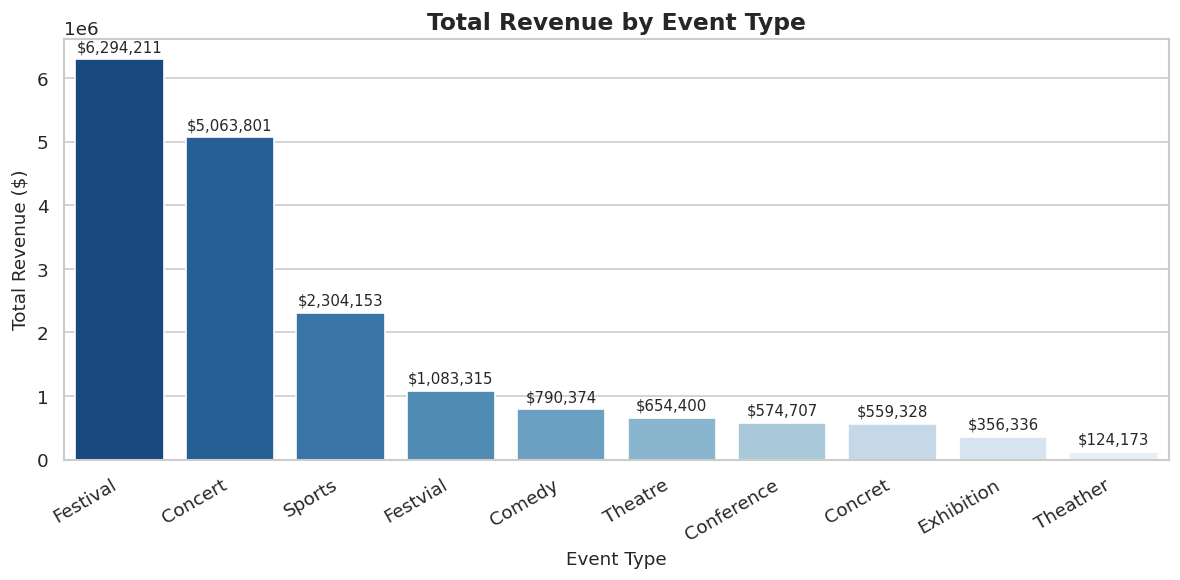

In [62]:
# 1. Aggregate revenue per event type
df_rev_type = (
    fact_sales
    .filter(F.col("order_status") != "cancelled")
    .groupBy("event_type")
    .agg(F.sum("total_amount").alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_rev_type, x="event_type", y="total_revenue", palette="Blues_r")
plt.title("Total Revenue by Event Type", fontsize=14, weight="bold")
plt.xlabel("Event Type", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.xticks(rotation=30, ha="right")

# Add data labels
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6945/3590875694.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_cust, x="lifetime_value", y="customer_name", palette="viridis")


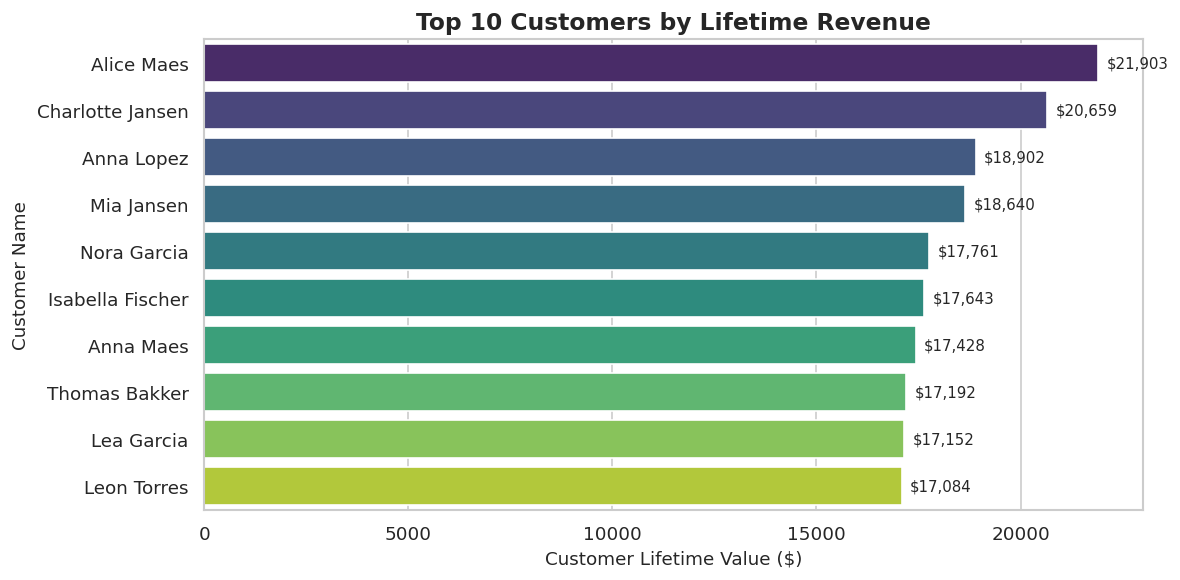

In [63]:
# 1. Window Function: Rank customers by Lifetime Value (LTV)
rank_window = Window.orderBy(F.desc("lifetime_value"))

top10_cust = (
    dim_customers
    .withColumn("cust_rank", F.row_number().over(rank_window))
    .filter(F.col("cust_rank") <= 10)
    .withColumn("customer_name", F.concat_ws(" ", "first_name", "last_name"))
    .select("customer_name", "lifetime_value", "cust_rank")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top10_cust, x="lifetime_value", y="customer_name", palette="viridis")
plt.title("Top 10 Customers by Lifetime Revenue", fontsize=14, weight="bold")
plt.xlabel("Customer Lifetime Value ($)", fontsize=11)
plt.ylabel("Customer Name", fontsize=11)

for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

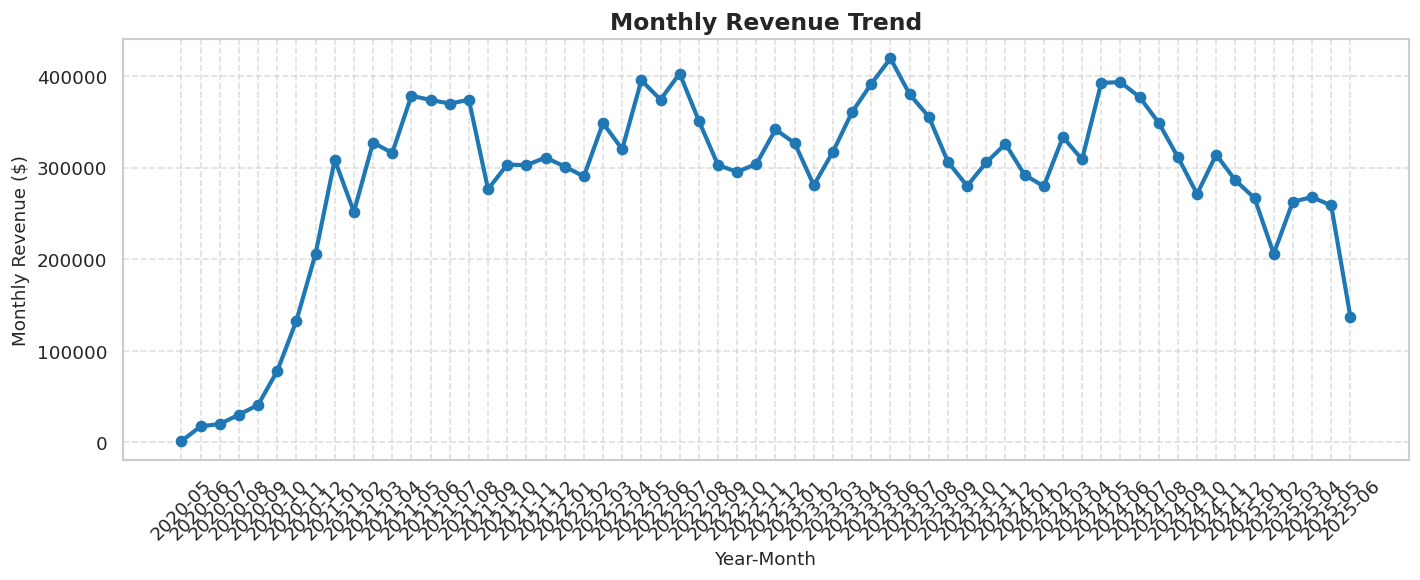

In [64]:
# 1. Aggregate completed revenue by Month
monthly_trend = (
    fact_sales
    .filter(F.col("order_status") != "cancelled")
    .withColumn("year_month", F.date_format("order_date", "yyyy-MM"))
    .groupBy("year_month")
    .agg(F.sum("total_amount").alias("monthly_revenue"))
    .orderBy("year_month")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["year_month"], monthly_trend["monthly_revenue"],
         marker="o", color="#1f77b4", linewidth=2.5, markersize=6)
plt.title("Monthly Revenue Trend", fontsize=14, weight="bold")
plt.xlabel("Year-Month", fontsize=11)
plt.ylabel("Monthly Revenue ($)", fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6945/492874080.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_cancel_country, x="country", y="cancellation_rate_pct", palette="Reds_r")


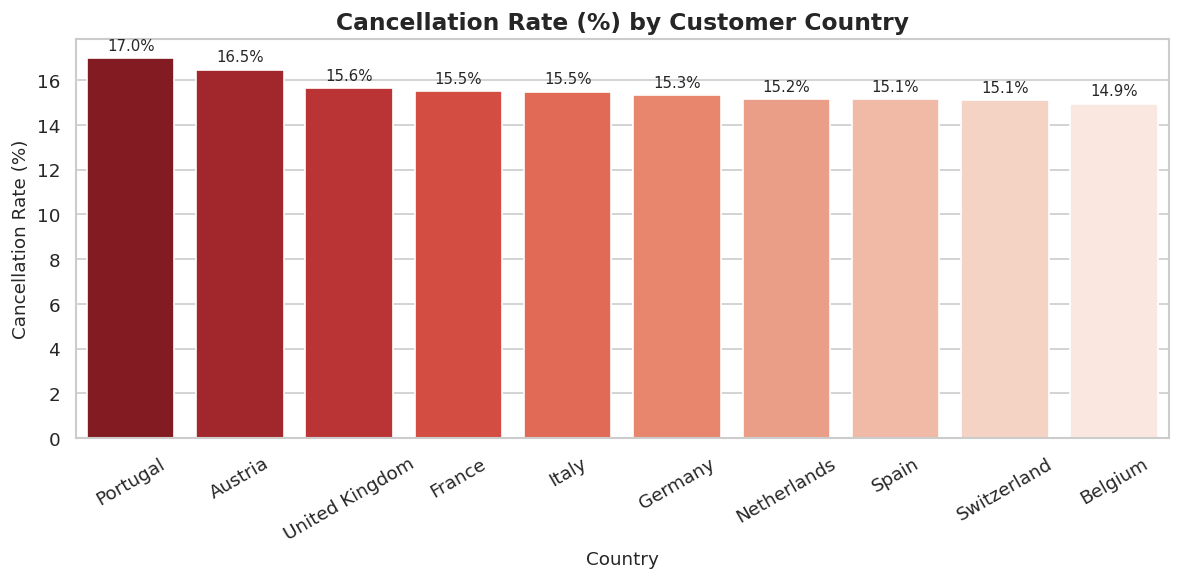

In [65]:
# 1. Join fact_sales with dim_customers to get customer country
df_cancel_country = (
    fact_sales
    .join(dim_customers, "customer_id", "left")
    .groupBy("country")
    .agg(
        F.count("order_id").alias("total_orders"),
        F.sum(F.when(F.col("cancellation_category").isin("On-time cancellation", "Late cancellation"), 1).otherwise(0)).alias("cancelled_orders")
    )
    .withColumn("cancellation_rate_pct", F.round((F.col("cancelled_orders") / F.col("total_orders")) * 100, 2))
    .filter(F.col("total_orders") > 5) # Filter out noise
    .orderBy(F.desc("cancellation_rate_pct"))
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_cancel_country, x="country", y="cancellation_rate_pct", palette="Reds_r")
plt.title("Cancellation Rate (%) by Customer Country", fontsize=14, weight="bold")
plt.xlabel("Country", fontsize=11)
plt.ylabel("Cancellation Rate (%)", fontsize=11)
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6945/3701128317.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_cities, x="total_revenue", y="city", palette="mako")


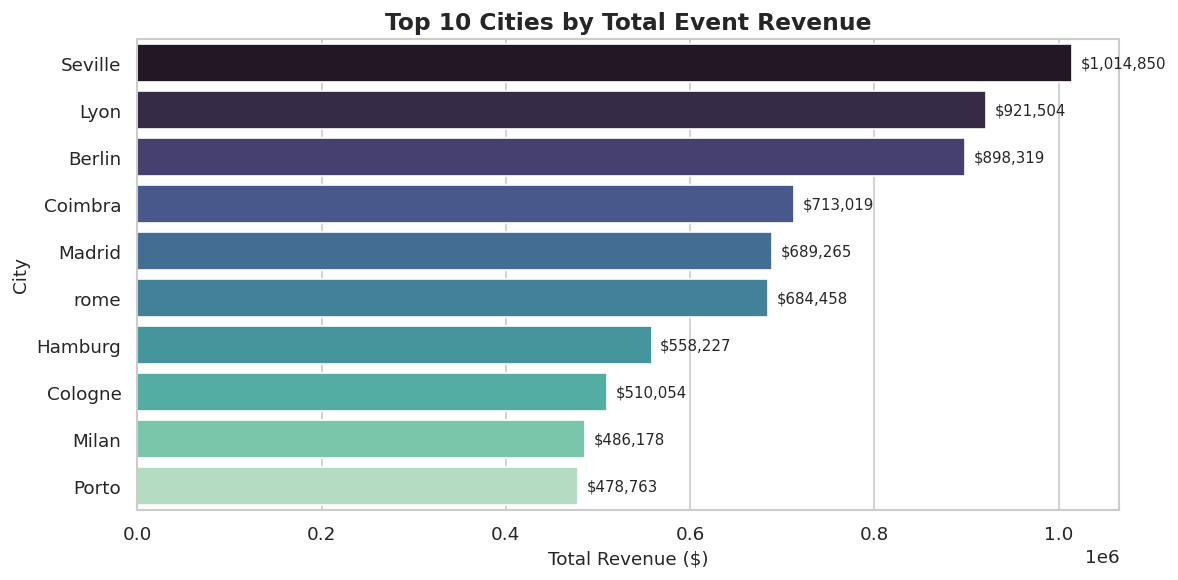

In [66]:
# 1. Join fact_sales with dim_events to aggregate venue city revenue
top10_cities = (
    fact_sales
    .join(dim_events, "event_id", "left")
    .filter(F.col("order_status") != "cancelled")
    .groupBy(dim_events.city)
    .agg(F.sum("total_amount").alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
    .limit(10)
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top10_cities, x="total_revenue", y="city", palette="mako")
plt.title("Top 10 Cities by Total Event Revenue", fontsize=14, weight="bold")
plt.xlabel("Total Revenue ($)", fontsize=11)
plt.ylabel("City", fontsize=11)

for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

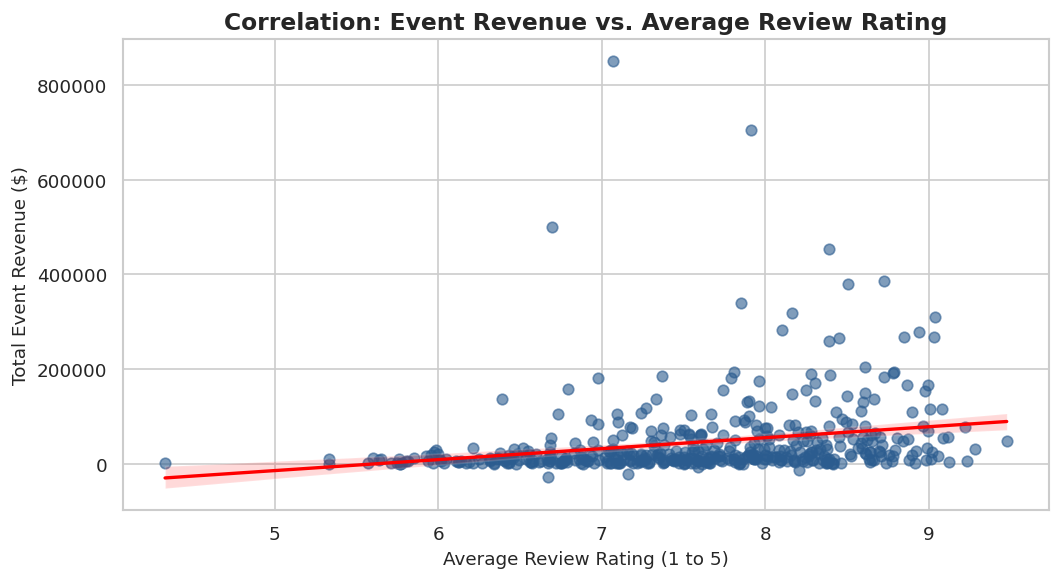

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# 1. Aggregate revenue & review score per event and cast to double
df_corr = (
    fact_sales
    .groupBy("event_id")
    .agg(
        F.sum("total_amount").cast("double").alias("event_revenue"),
        F.avg("review_score").cast("double").alias("avg_rating")
    )
    .filter(F.col("avg_rating").isNotNull() & F.col("event_revenue").isNotNull())
    .toPandas()
)

# 2. Ensure numeric types in Pandas and drop any NaNs
df_corr["avg_rating"] = pd.to_numeric(df_corr["avg_rating"], errors="coerce")
df_corr["event_revenue"] = pd.to_numeric(df_corr["event_revenue"], errors="coerce")
df_corr = df_corr.dropna(subset=["avg_rating", "event_revenue"])

# 3. Plot
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_corr,
    x="avg_rating",
    y="event_revenue",
    color="#2b5c8f",
    scatter_kws={"alpha": 0.6, "s": 40},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Correlation: Event Revenue vs. Average Review Rating", fontsize=14, weight="bold")
plt.xlabel("Average Review Rating (1 to 5)", fontsize=11)
plt.ylabel("Total Event Revenue ($)", fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6945/624905607.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ltv_dist, x="ltv_segment", y="customer_count", palette="Set2", ax=ax1)
/tmp/ipykernel_6945/624905607.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ltv_dist, x="ltv_segment", y="segment_revenue", palette="Set2", ax=ax2)


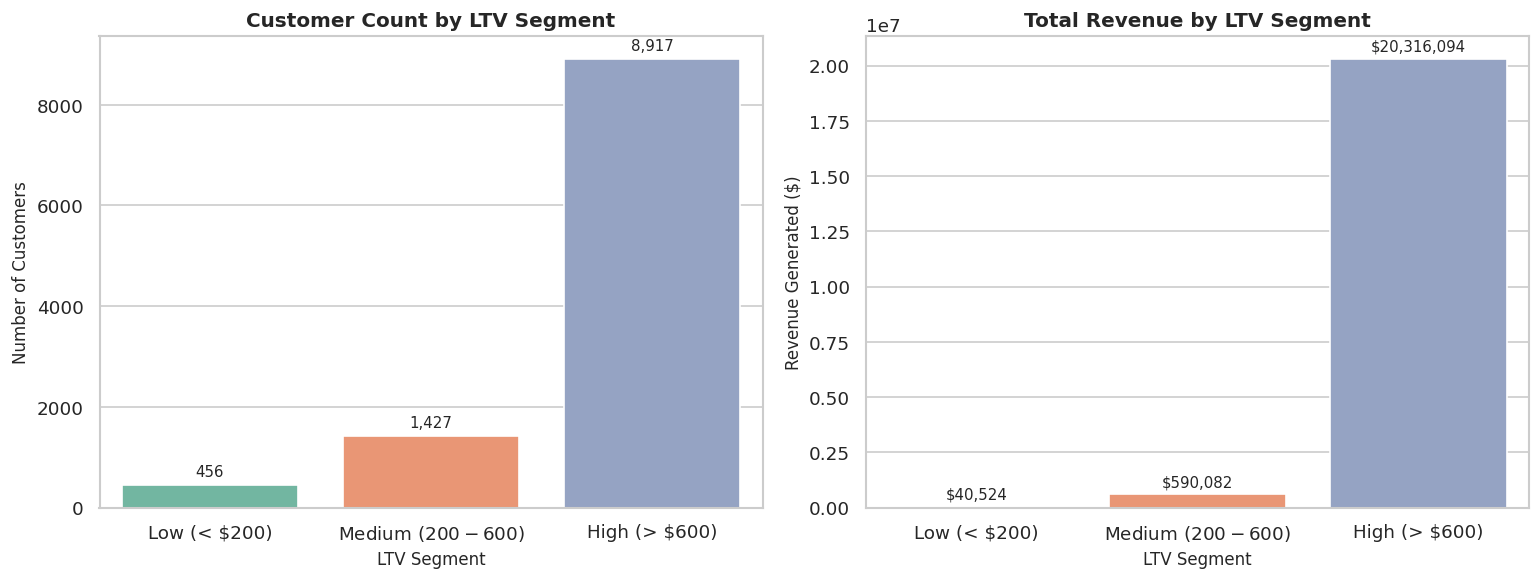

In [69]:
# 1. Categorize customers using CASE / WHEN logic
df_ltv_dist = (
    dim_customers
    .withColumn(
        "ltv_segment",
        F.when(F.col("lifetime_value") < 200, "Low (< $200)")
         .when((F.col("lifetime_value") >= 200) & (F.col("lifetime_value") <= 600), "Medium ($200 - $600)")
         .otherwise("High (> $600)")
    )
    .groupBy("ltv_segment")
    .agg(
        F.count("customer_id").alias("customer_count"),
        F.sum("lifetime_value").alias("segment_revenue")
    )
    .toPandas()
)

# Sort order
order_map = {"Low (< $200)": 0, "Medium ($200 - $600)": 1, "High (> $600)": 2}
df_ltv_dist["sort"] = df_ltv_dist["ltv_segment"].map(order_map)
df_ltv_dist = df_ltv_dist.sort_values("sort")

# 2. Plot (Two Subplots: Customer Share vs Revenue Share)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot A: Customer Count
sns.barplot(data=df_ltv_dist, x="ltv_segment", y="customer_count", palette="Set2", ax=ax1)
ax1.set_title("Customer Count by LTV Segment", fontsize=12, weight="bold")
ax1.set_xlabel("LTV Segment", fontsize=10)
ax1.set_ylabel("Number of Customers", fontsize=10)

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                 textcoords='offset points')

# Plot B: Segment Total Revenue
sns.barplot(data=df_ltv_dist, x="ltv_segment", y="segment_revenue", palette="Set2", ax=ax2)
ax2.set_title("Total Revenue by LTV Segment", fontsize=12, weight="bold")
ax2.set_xlabel("LTV Segment", fontsize=10)
ax2.set_ylabel("Revenue Generated ($)", fontsize=10)

for p in ax2.patches:
    ax2.annotate(f"${p.get_height():,.0f}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                 textcoords='offset points')

plt.tight_layout()
plt.show()